In [46]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.varmax import VARMAX
# from statsmodels.graphics.tsaplots import plot_acf, plot_ccf
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
# from tqdm import tqdm_notebook
# from itertools import product
from warnings import filterwarnings

import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
# import statsmodels.api as sm

filterwarnings('ignore')

In [32]:
filepath = 'https://raw.githubusercontent.com/selva86/datasets/master/Raotbl6.csv'
macro_data = pd.read_csv(filepath, parse_dates=['date'], index_col='date')
print(macro_data.shape)  # (123, 8)
macro_data

(123, 8)


,rgnp,pgnp,ulc,gdfco,gdf,gdfim,gdfcf,gdfce
date,,,,,,,,
1959-01-01,1606.4,1608.3,47.5,36.9,37.4,26.9,32.3,23.1
1959-04-01,1637.0,1622.2,47.5,37.4,37.5,27.0,32.2,23.4
1959-07-01,1629.5,1636.2,48.7,37.6,37.6,27.1,32.4,23.4
1959-10-01,1643.4,1650.3,48.8,37.7,37.8,27.1,32.5,23.8
1960-01-01,1671.6,1664.6,49.1,37.8,37.8,27.2,32.4,23.8
...,...,...,...,...,...,...,...,...
1988-07-01,4042.7,3971.9,179.6,131.5,124.9,106.2,123.5,92.8
1988-10-01,4069.4,3995.8,181.3,133.3,126.2,107.3,124.9,92.9
1989-01-01,4106.8,4019.9,184.1,134.8,127.7,109.5,126.6,94.0


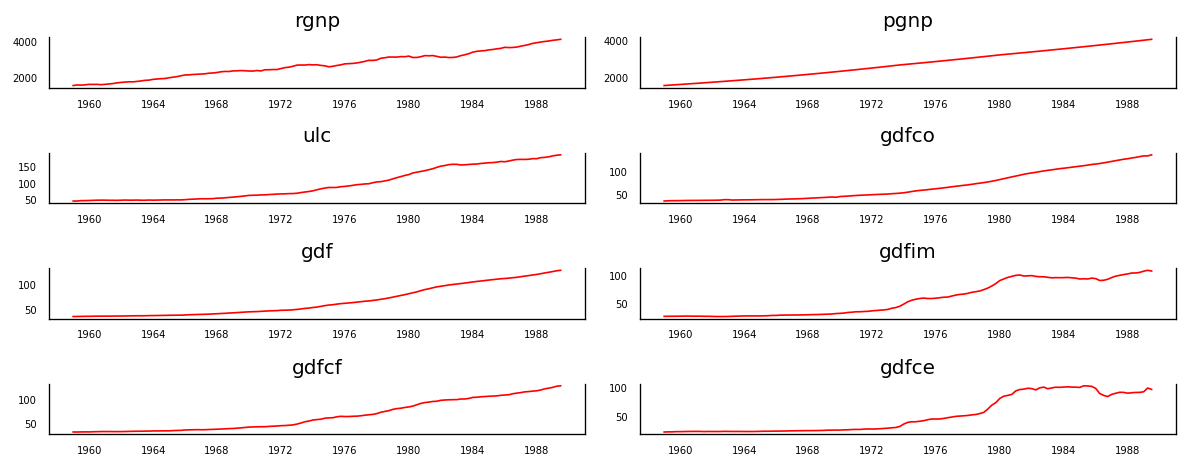

In [33]:
fig, axes = plt.subplots(nrows=4, ncols=2, dpi=120, figsize=(10,4))
for i ,ax in enumerate(axes.flatten()):
    data = macro_data[macro_data.columns[i]]
    ax.plot(data, color='red', linewidth=1)
    # Decorations
    ax.set_title(macro_data.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)
plt.tight_layout()

Use augmented-dickey-fuler test for stationarity, and use differencing to difference the timeseries with itself, by n, so that it becomes stationary.

In [34]:
ad_fuller_result_1 = adfuller(macro_data['rgnp'].diff()[1:])

print('rgnp')
print(f'ADF Statistic: {ad_fuller_result_1[0]}')
print(f'p-value: {ad_fuller_result_1[1]}')

print('\n---------------------\n')

ad_fuller_result_2 = adfuller(macro_data['ulc'].diff()[1:])

print('ulc')
print(f'ADF Statistic: {ad_fuller_result_2[0]}')
print(f'p-value: {ad_fuller_result_2[1]}')

rgnp
ADF Statistic: -5.427594381007333
p-value: 2.9633019848469254e-06

---------------------

ulc
ADF Statistic: -3.576080473150911
p-value: 0.006235131830238172


To check the correlation between two series, use granger causality test

In [35]:
print('rgnp causes ulc?\n')
print('------------------')
granger_1 = grangercausalitytests(macro_data[['ulc', 'rgnp']], 4)

print('\nulc causes rgnp?\n')
print('------------------')
granger_2 = grangercausalitytests(macro_data[['rgnp', 'ulc']], 4)
granger_1, granger_2

rgnp causes ulc?

------------------

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=22.3802 , p=0.0000  , df_denom=119, df_num=1
ssr based chi2 test:   chi2=22.9444 , p=0.0000  , df=1
likelihood ratio test: chi2=21.0242 , p=0.0000  , df=1
parameter F test:         F=22.3802 , p=0.0000  , df_denom=119, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=7.7188  , p=0.0007  , df_denom=116, df_num=2
ssr based chi2 test:   chi2=16.1029 , p=0.0003  , df=2
likelihood ratio test: chi2=15.1179 , p=0.0005  , df=2
parameter F test:         F=7.7188  , p=0.0007  , df_denom=116, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=7.5231  , p=0.0001  , df_denom=113, df_num=3
ssr based chi2 test:   chi2=23.9675 , p=0.0000  , df=3
likelihood ratio test: chi2=21.8515 , p=0.0001  , df=3
parameter F test:         F=7.5231  , p=0.0001  , df_denom=113, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F

({1: ({'ssr_ftest': (22.38020029002665, 6.209764040394385e-06, 119.0, 1),
    'ssr_chi2test': (22.944407020027324, 1.6675467783135184e-06, 1),
    'lrtest': (21.024165365688077, 4.535269042084533e-06, 1),
    'params_ftest': (22.380200290026963, 6.209764040393622e-06, 119.0, 1.0)},
    array([[0., 1., 0.]])]),
  2: ({'ssr_ftest': (7.718768802305952, 0.0007125861002763685, 116.0, 2),
    'ssr_chi2test': (16.10294870825897, 0.0003186317998928159, 2),
    'lrtest': (15.117927363553918, 0.0005214153161872317, 2),
    'params_ftest': (7.718768802297159, 0.0007125861002819005, 116.0, 2.0)},
    array([[0., 0., 1., 0., 0.],
           [0., 0., 0., 1., 0.]])]),
  3: ({'ssr_ftest': (7.523123712926997, 0.00012349246768897747, 113.0, 3),
    'ssr_chi2test': (23.967473775696625, 2.537362226260102e-05, 3),
    'lrtest': (21.85147856668084, 7.004120985620657e-05, 3),
    'params_ftest': (7.523123712920527, 0.0001234924676899357, 113.0, 3.0)},
    array([[0., 0., 0., 1., 0., 0., 0.],
           [0., 

In [36]:
macro_data = macro_data[['ulc','rgnp']]
print(macro_data.shape)

(123, 2)


In [37]:
train_df=macro_data[:-12]
test_df=macro_data[-12:]

In [38]:
model = VAR(train_df.diff()[1:])

In [39]:
sorted_order=model.select_order(maxlags=20)
print(sorted_order.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        6.778       6.834       878.3       6.800
1        5.988      6.154*       398.5       6.055
2        5.942       6.220       380.9       6.054
3        5.933       6.322       377.4       6.090
4       5.793*       6.293      328.5*      5.995*
5        5.873       6.484       356.3       6.120
6        5.828       6.550       341.1       6.119
7        5.894       6.727       365.0       6.230
8        5.890       6.835       364.8       6.271
9        5.942       6.998       385.8       6.368
10       5.930       7.097       382.9       6.401
11       5.913       7.191       378.5       6.428
12       5.885       7.274       370.7       6.445
13       5.925       7.424       388.6       6.529
14       5.882       7.493       376.0       6.532
15       5.950       7.672       406.9       6.644
16       5.933       7.766     

At lag 4 for we've got minimum AIC, FPE, HQIC results and for auto regression (p), we'll p=4, for moving average, which we're not dealing with, as of now, take is 0.

In [40]:
var_model = VARMAX(train_df, order=(4,0),enforce_stationarity= True)
fitted_model = var_model.fit(disp=False)
print(fitted_model.summary())

                           Statespace Model Results                           
Dep. Variable:        ['ulc', 'rgnp']   No. Observations:                  111
Model:                         VAR(4)   Log Likelihood              -12096.470
                          + intercept   AIC                          24234.940
Date:                Fri, 01 Nov 2024   BIC                          24291.840
Time:                        21:56:26   HQIC                         24258.023
Sample:                    01-01-1959                                         
                         - 07-01-1986                                         
Covariance Type:                  opg                                         
Ljung-Box (L1) (Q):          30.09, 106.31   Jarque-Bera (JB):         88.99, 13.43
Prob(Q):                        0.00, 0.00   Prob(JB):                   0.00, 0.00
Heteroskedasticity (H):         0.96, 0.29   Skew:                      1.16, -0.85
Prob(H) (two-sided):            0.90,

In [41]:
n_forecast = 12
predict = fitted_model.get_prediction(start=len(train_df),end=len(train_df) + n_forecast-1)#start="1989-07-01",end='1999-01-01')

predictions=predict.predicted_mean
predictions

,ulc,rgnp
1986-10-01,165.249484,3576.342577
1987-01-01,235.402942,3745.223489
1987-04-01,65.743257,3573.694936
1987-07-01,255.494040,3840.207037
1987-10-01,142.392118,3492.882575
1988-01-01,184.808501,3774.247839
1988-04-01,144.126838,3611.631644
1988-07-01,209.439243,3747.634267
1988-10-01,141.984992,3560.885568
1989-01-01,200.024470,3767.196368


In [42]:
predictions.columns=['ulc_predicted','rgnp_predicted']
predictions

,ulc_predicted,rgnp_predicted
1986-10-01,165.249484,3576.342577
1987-01-01,235.402942,3745.223489
1987-04-01,65.743257,3573.694936
1987-07-01,255.494040,3840.207037
1987-10-01,142.392118,3492.882575
1988-01-01,184.808501,3774.247839
1988-04-01,144.126838,3611.631644
1988-07-01,209.439243,3747.634267
1988-10-01,141.984992,3560.885568
1989-01-01,200.024470,3767.196368


In [43]:
test_vs_pred=pd.concat([test_df,predictions],axis=1)
test_vs_pred

,ulc,rgnp,ulc_predicted,rgnp_predicted
1986-10-01,173.2,3733.6,165.249484,3576.342577
1987-01-01,173.6,3783.0,235.402942,3745.223489
1987-04-01,173.4,3823.5,65.743257,3573.694936
1987-07-01,173.9,3872.8,255.494040,3840.207037
1987-10-01,175.8,3935.6,142.392118,3492.882575
1988-01-01,175.7,3974.8,184.808501,3774.247839
1988-04-01,178.7,4010.7,144.126838,3611.631644
1988-07-01,179.6,4042.7,209.439243,3747.634267
1988-10-01,181.3,4069.4,141.984992,3560.885568
1989-01-01,184.1,4106.8,200.024470,3767.196368


<Axes: >

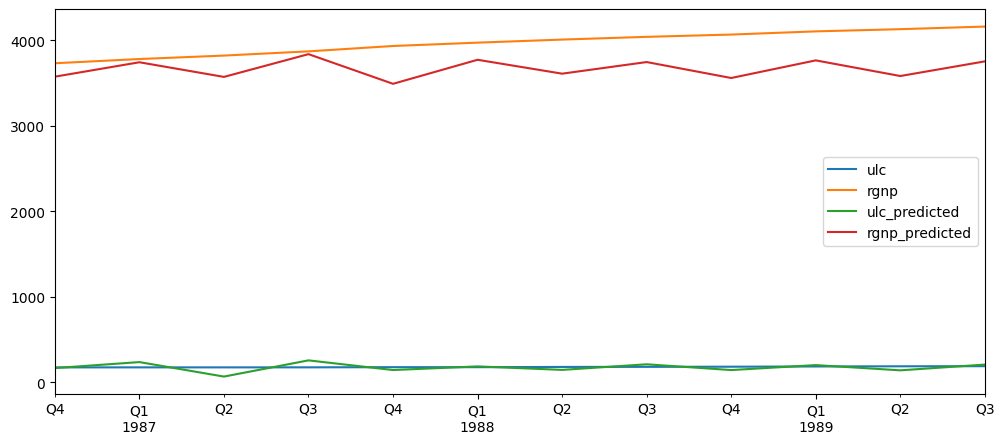

In [44]:
test_vs_pred.plot(figsize=(12,5))

In [45]:
from sklearn.metrics import mean_squared_error
import math
from statistics import mean

rmse_ulc=math.sqrt(mean_squared_error(predictions['ulc_predicted'],test_df['ulc']))
print('Mean value of ULC is : {}. Root Mean Squared Error is :{}'.format(mean(test_df['ulc']),rmse_ulc))

rmse_rgnp=math.sqrt(mean_squared_error(predictions['rgnp_predicted'],test_df['rgnp']))
print('Mean value of RGNP is : {}. Root Mean Squared Error is :{}'.format(mean(test_df['rgnp']),rmse_rgnp))

Mean value of ULC is : 178.56666666666666. Root Mean Squared Error is :49.83102158158002
Mean value of RGNP is : 3970.6916666666666. Root Mean Squared Error is :343.1073555484267
